In [4]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("KAKAO_REST_API_KEY"))

73923fe6c9aff51e1c382ad85842e6ce


In [2]:
# 테스트용 초기 state 만들기
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [3]:
# [노드] preprocess_input
# 사용자 입력 전처리 (변수값 매핑 + 키워드 및 반경 설정)
from nodes.preprocess_input import preprocess_input

preprocess_result = preprocess_input(initial_state)
print("preprocess_input 결과:", preprocess_result)


preprocess_input 결과: {'user_input': {'destination': '해운대역', 'lat': 35.1631, 'lng': 129.1635, 'travel_days': 2, 'companion': 'couple', 'age_group': '20s', 'moods': ['active', 'healing', 'clean'], 'activities': ['thrill/experience', 'performance/culture', 'entertainment/sports', 'nature/walk'], 'transport': 'walk', 'avoid_activities': [], 'start_time': '09:00', 'end_time': '22:00', 'center_lat': 35.1631, 'center_lng': 129.1635, 'search_radius_km': 1.0, 'final_keywords': ['맛집', '카페', '스릴/체험', '공연/문화', '오락/스포츠', '자연/산책', '숙박'], 'companion_kr': '연인', 'age_group_kr': '20대', 'moods_kr': ['활기찬', '힐링', '깔끔한'], 'activities_kr': ['스릴/체험', '공연/문화', '오락/스포츠', '자연/산책'], 'transport_kr': '도보', 'duration_kr': '1박2일'}, 'warnings': [], 'step': 'preprocessed'}


In [4]:
# [노드] collect_candidate_pool
# kakao Local API로 raw 후보 풀 수집 + PostgreSQL
from nodes.collect_candidate_pool import collect_candidate_pool

candidates_result = await collect_candidate_pool(preprocess_result)
print("candidates_result 결과:", candidates_result)


candidates_result 결과: {'user_input': {'destination': '해운대역', 'lat': 35.1631, 'lng': 129.1635, 'travel_days': 2, 'companion': 'couple', 'age_group': '20s', 'moods': ['active', 'healing', 'clean'], 'activities': ['thrill/experience', 'performance/culture', 'entertainment/sports', 'nature/walk'], 'transport': 'walk', 'avoid_activities': [], 'start_time': '09:00', 'end_time': '22:00', 'center_lat': 35.1631, 'center_lng': 129.1635, 'search_radius_km': 1.0, 'final_keywords': ['맛집', '음식점', '카페', '찻집', '짚라인', '번지점프', '놀이공원', '워터파크', '테마파크', 'VR체험', '이색체험', '공연장', '극장', '콘서트홀', '라이브하우스', '영화관', '오락실', '볼링장', '당구장', '사격장', '스포츠 시설', '클라이밍', 'PC방', '노래방', '공원', '산책로', '둘레길', '식물원', '해변', '바다', '해수욕장', '등산', '산', '계곡', '숙박', '호텔', '게스트하우스', '펜션', '리조트'], 'companion_kr': '연인', 'age_group_kr': '20대', 'moods_kr': ['활기찬', '힐링', '깔끔한'], 'activities_kr': ['스릴/체험', '공연/문화', '오락/스포츠', '자연/산책'], 'transport_kr': '도보', 'duration_kr': '1박2일'}, 'candidates': [{'id': '11892127', 'name': '신흥관', 'category': '음식점 

In [5]:
# [노드] first_filter_candidates
# 첫번쨰 필터 -> 50개 축소
from nodes.first_filter_candidates import first_filter_candidates

filter_result = first_filter_candidates(candidates_result, debug=True)

print(f"\n📌 warnings:")
for w in filter_result["warnings"]:
    print(f"   - {w}")


📦 시작
   ──────────────────────────────────────────────────
   ✂️  제거: 0개  |  남은: 374개
   📊 카테고리: AD5:114  :108  FD6:72  CE7:64  CT1:7  PK6:4
🔍 전체 장소 목록:
01. [FD6] 신흥관 | 음식점 > 중식 > 중국요리
02. [FD6] 부다면옥 | 음식점 > 한식 > 냉면
03. [FD6] 금수복국 해운대본점 | 음식점 > 한식 > 해물,생선 > 복어
04. [FD6] 해운대밀면 | 음식점 > 한식 > 국수
05. [FD6] 해운대암소갈비집 | 음식점 > 한식 > 육류,고기 > 갈비
06. [FD6] 거대갈비 | 음식점 > 한식 > 육류,고기 > 갈비
07. [FD6] 빨간떡볶이 | 음식점 > 분식 > 떡볶이
08. [FD6] 해목 | 음식점 > 일식
09. [FD6] 가온밀면 해운대점 | 음식점 > 한식 > 국수
10. [FD6] 해운대할매집 | 음식점 > 한식 > 국밥
11. [FD6] 가야밀면 | 음식점 > 한식 > 국수
12. [FD6] 해운대31cm해물칼국수 직영1호점 | 음식점 > 한식 > 국수 > 칼국수
13. [FD6] 행복식당 2호점 | 음식점 > 한식 > 해물,생선 > 조개
14. [FD6] 옵스 해운대점 | 음식점 > 간식 > 제과,베이커리
15. [FD6] 봉자네실비집 | 음식점 > 한식
16. [FD6] 데일리팡 해운대본점 | 음식점 > 간식 > 제과,베이커리
17. [FD6] 해운대원조할매국밥 | 음식점 > 한식 > 국밥
18. [FD6] 오복돼지국밥 | 음식점 > 한식 > 국밥
19. [FD6] 해운대어가횟집 | 음식점 > 한식 > 해물,생선 > 회
20. [FD6] 김해김가네뒷고기 | 음식점 > 한식 > 육류,고기
21. [FD6] 해운대 남천집 | 음식점 > 한식 > 해물,생선
22. [FD6] 해성막창집 본점 | 음식점 > 한식 > 육류,고기 > 곱창,막창
23. [CE7] 블랙업커피 해운대점 | 음식점 > 카페 >

In [7]:
# [노드] second_filter_candidates
# 두번쨰 필터 -> 30개 축소
from nodes.second_filter_candidates import second_filter_candidates

test_state = {
    "filtered_candidates": filter_result["filtered_candidates"],
    "user_input": mock_user_input,
    "warnings": [],
}

second_filter_result = await second_filter_candidates(test_state)

print(f"⚠️ warnings: {second_filter_result['warnings']}")
print(f"✅ step: {second_filter_result['step']}")
print(f"📦 보강된 장소 수: {len(second_filter_result['filtered_candidates'])}")
print(f"📊 scored_candidates 수: {len(second_filter_result['scored_candidates'])}")
print(f"🏆 shortlist 수: {len(second_filter_result['shortlist'])}")

print("\n=== 전체 scored_candidates (50개) ===")

for i, s in enumerate(second_filter_result["scored_candidates"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  분위기: {p.get('atmosphere')}
  추천대상: {p.get('best_for')}
  활동: {p.get('place_tags')}
  재방문의사: {p.get('revisit_intent')}
  한줄요약: {p.get('summary')}
  mood_score: {s['mood_score']}
  activity_score: {s['activity_score']}
  party_fit_score: {s['party_fit_score']}
  total_score: {s['total_score']}
""")


print("\n=== shortlist (최종 30개) ===")

for i, s in enumerate(second_filter_result["shortlist"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  total_score: {s['total_score']}
  bucket: {p.get('bucket')}
""")

⏱  네이버 블로그: 11.4초 (50개)
⏱  LLM 보강: 20.1초 (50개)
⚠️ warnings: []
✅ step: enriched
📦 보강된 장소 수: 50
📊 scored_candidates 수: 50
🏆 shortlist 수: 30

=== 전체 scored_candidates (50개) ===

1위. 나가하마만게츠
  분위기: ['이색', '힐링']
  추천대상: ['혼자', '연인']
  활동: ['일식', '라면', '해운대']
  재방문의사: high
  한줄요약: 이색적인 일본식 라면 맛집으로 혼자 또는 연인과 방문.
  mood_score: 20
  activity_score: 0
  party_fit_score: 40
  total_score: 90


2위. 카페히토
  분위기: ['감성', '조용한', '힐링']
  추천대상: ['연인', '혼자']
  활동: ['일본풍', '카페', '커피']
  재방문의사: high
  한줄요약: 고풍스러운 일본풍 카페에서 여유롭게 커피를 즐길 수 있다.
  mood_score: 10
  activity_score: 10
  party_fit_score: 40
  total_score: 90


3위. 워킹홀리데이 해운대
  분위기: ['힐링', '로맨틱']
  추천대상: ['연인']
  활동: ['오션뷰', '해운대', '카페']
  재방문의사: high
  한줄요약: 해운대 바다뷰에서 힐링할 수 있는 카페이다.
  mood_score: 10
  activity_score: 10
  party_fit_score: 40
  total_score: 90


4위. 바다내음공원
  분위기: ['힐링', '조용한']
  추천대상: ['연인', '혼자']
  활동: ['공원', '바다', '뷰']
  재방문의사: high
  한줄요약: 바다와 광안대교를 동시에 즐길 수 있는 공원.
  mood_score: 10
  activity_score: 10
  party_fit_score: 40
  tot

In [8]:
# [노드] travel_matrix
# shortlist 30개 장소 간 이동시간 행렬 계산
from nodes.travel_matrix import travel_matrix

matrix_result = travel_matrix(second_filter_result)

# place_id → name 매핑
id_to_name = {item["place"]["id"]: item["place"]["name"] for item in second_filter_result["shortlist"]}

print(f"✅ place_index: {len(matrix_result['place_index'])}개")
print(f"✅ distance_matrix: {len(matrix_result['distance_matrix'])}x{len(matrix_result['distance_matrix'][0])}")
print(f"✅ time_matrix: {len(matrix_result['time_matrix'])}x{len(matrix_result['time_matrix'][0])}")

for i, from_id in enumerate(matrix_result['place_index']):
    print(f"\n📍 {id_to_name[from_id]} 에서:")
    for to_id, mins in zip(matrix_result['place_index'], matrix_result['time_matrix'][i]):
        if from_id == to_id:
            continue
        print(f"  → {id_to_name[to_id]}: {mins}분")

✅ place_index: 30개
✅ distance_matrix: 30x30
✅ time_matrix: 30x30

📍 카페히토 에서:
  → 워킹홀리데이 해운대: 9.6분
  → 나가하마만게츠: 5.0분
  → 바다내음공원: 21.8분
  → 딥플로우커피: 3.2분
  → 강릉송정해변막국수 부산분점: 22.4분
  → 한어부의고등어사랑: 3.1분
  → 플레이포인트랩 해운대 블루오션스테이션점: 3.2분
  → 해운대블루라인파크 미포정거장: 24.4분
  → 동백공원 해안산책로: 16.0분
  → 할매탕: 11.9분
  → 씨라이프 부산아쿠아리움: 9.7분
  → 해운대해수욕장: 9.9분
  → 바다위구름상점: 9.4분
  → 해운대 바다김밥: 9.7분
  → 왕미미오락실: 6.3분
  → 민트플레이 해운대2호점: 3.2분
  → 사격팡 해운대점: 8.0분
  → 봉봉스테이션 해운대점: 17.4분
  → 오션스타: 9.7분
  → 카페해운대1994: 3.2분
  → 로우앤스윗 로스터리: 2.0분
  → 빨간떡볶이: 6.5분
  → 해목: 5.6분
  → 칠암만장 해운대: 3.7분
  → 해운대원조할매국밥: 6.9분
  → 하브커피: 1.7분
  → 블랙업커피 해운대점: 11.0분
  → 해변문화관: 9.4분
  → 해운대광장 고운바다길분수: 7.4분

📍 워킹홀리데이 해운대 에서:
  → 카페히토: 9.6분
  → 나가하마만게츠: 12.4분
  → 바다내음공원: 14.4분
  → 딥플로우커피: 9.0분
  → 강릉송정해변막국수 부산분점: 15.5분
  → 한어부의고등어사랑: 7.4분
  → 플레이포인트랩 해운대 블루오션스테이션점: 6.7분
  → 해운대블루라인파크 미포정거장: 15.6분
  → 동백공원 해안산책로: 14.5분
  → 할매탕: 7.2분
  → 씨라이프 부산아쿠아리움: 1.2분
  → 해운대해수욕장: 3.3분
  → 바다위구름상점: 2.3분
  → 해운대 바다김밥: 5.0분
  → 왕미미오락실: 4.0분
  → 민트플레이 해운대2호점: 6.7분


In [9]:
# [노드] plan_itinerary
from nodes.plan_itinerary import plan_itinerary

# travel_matrix 결과 + user_input 합치기
plan_state = {**matrix_result, "shortlist": second_filter_result["shortlist"], "user_input": second_filter_result["user_input"]}
itinerary_result = plan_itinerary(plan_state)

print(f"✅ 총 {len(itinerary_result['itinerary'])}개 장소")
print()
for item in itinerary_result["itinerary"]:
    p = item["place"]
    print(f"{item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
    print(f"   도착: {item['arrive_at']}  출발: {item['leave_at']}  다음까지: {item['travel_to_next_minutes']}분")
    print()

✅ 총 9개 장소

1. [activity] 사격팡 해운대점
   도착: 09:00  출발: 11:00  다음까지: 1분

2. [cafe    ] 워킹홀리데이 해운대
   도착: 11:01  출발: 12:01  다음까지: 5분

3. [food    ] 해운대 바다김밥
   도착: 12:06  출발: 13:06  다음까지: 2분

4. [activity] 할매탕
   도착: 13:09  출발: 15:09  다음까지: 4분

5. [food    ] 해운대원조할매국밥
   도착: 15:14  출발: 16:14  다음까지: 6분

6. [cafe    ] 카페히토
   도착: 16:21  출발: 17:21  다음까지: 3분

7. [cafe    ] 딥플로우커피
   도착: 17:24  출발: 18:24  다음까지: 2분

8. [activity] 플레이포인트랩 해운대 블루오션스테이션점
   도착: 18:27  출발: 20:27  다음까지: 0분

9. [cafe    ] 카페해운대1994
   도착: 20:27  출발: 21:27  다음까지: 0분



In [10]:
# [노드] constraint_check
from nodes.constraint_check import constraint_check

constraint_state = {
    **itinerary_result,
    "shortlist": second_filter_result["shortlist"],
    "user_input": second_filter_result["user_input"],
    "excluded_ids": [],
    "retry_count": 0,
}
constraint_result = constraint_check(constraint_state)

print(f"✅ next_node: {constraint_result['next_node']}")
print(f"✅ step: {constraint_result['step']}")
print()
if constraint_result["violations"]:
    print("❌ violations:")
    for v in constraint_result["violations"]:
        print(f"  - {v['reason']}: {v['detail']}")
else:
    print("✅ 모든 체크 통과")

✅ next_node: plan_itinerary
✅ step: constraint_failed

❌ violations:
  - 경로 교차: 해운대원조할매국밥 → 카페히토 와 딥플로우커피 → 플레이포인트랩 해운대 블루오션스테이션점 교차


In [11]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END
from core.state import TravelState

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("preprocess_input", preprocess_input)
graph_builder.add_node("collect_candidate_pool", collect_candidate_pool)
graph_builder.add_node("first_filter_candidates", first_filter_candidates)
graph_builder.add_node("second_filter_candidates", second_filter_candidates)
graph_builder.add_node("travel_matrix", travel_matrix)
graph_builder.add_node("plan_itinerary", plan_itinerary)
graph_builder.add_node("constraint_check", constraint_check)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "preprocess_input")
graph_builder.add_edge("preprocess_input", "collect_candidate_pool")
graph_builder.add_edge("collect_candidate_pool", "first_filter_candidates")
graph_builder.add_edge("first_filter_candidates", "second_filter_candidates")
graph_builder.add_edge("second_filter_candidates", "travel_matrix")
graph_builder.add_edge("travel_matrix", "plan_itinerary")
graph_builder.add_edge("plan_itinerary", "constraint_check")

# 조건부 엣지 (constraint_check → next_node 기반 분기)
graph_builder.add_conditional_edges(
    "constraint_check",
    lambda state: state["next_node"],
    {
        "generate_response": END,
        "plan_itinerary": "plan_itinerary",
        "second_filter_candidates": "second_filter_candidates",
    }
)

graph = graph_builder.compile()

In [12]:
# 그래프 실행
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"✅ step: {state_v1['step']}")
print(f"✅ next_node: {state_v1.get('next_node', '')}")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print()

print(f"📋 itinerary ({len(state_v1['itinerary'])}개 장소):")
for item in state_v1["itinerary"]:
    p = item["place"]
    print(f"  {item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
    print(f"     도착: {item['arrive_at']}  출발: {item['leave_at']}  다음까지: {item['travel_to_next_minutes']}분")

if state_v1.get("violations"):
    print(f"\n❌ violations:")
    for v in state_v1["violations"]:
        print(f"  - {v['reason']}: {v['detail']}")

⏱  네이버 블로그: 10.5초 (50개)
⏱  LLM 보강: 16.2초 (50개)
⏱  네이버 블로그: 10.4초 (50개)
⏱  LLM 보강: 16.6초 (50개)
⏱  네이버 블로그: 10.5초 (50개)
⏱  LLM 보강: 15.3초 (50개)
📍 위치: 해운대역
📌 좌표: (35.1636479638612, 129.158897240251)
🔍 Kakao raw 후보: 275개
✅ step: constraint_passed
✅ next_node: 
⚠️  warnings: []
❌ errors: []

📋 itinerary (9개 장소):
  1. [cafe    ] 블랙업커피 해운대점
     도착: 09:00  출발: 10:00  다음까지: 0분
  2. [activity] 할매탕
     도착: 10:00  출발: 12:00  다음까지: 7분
  3. [food    ] 빨간떡볶이
     도착: 12:08  출발: 13:08  다음까지: 3분
  4. [cafe    ] 딥플로우커피
     도착: 13:11  출발: 14:11  다음까지: 2분
  5. [activity] 플레이포인트랩 해운대 블루오션스테이션점
     도착: 14:14  출발: 16:14  다음까지: 1분
  6. [food    ] 고래사어묵 해운대점
     도착: 16:15  출발: 17:15  다음까지: 5분
  7. [cafe    ] 워킹홀리데이 해운대
     도착: 17:21  출발: 18:21  다음까지: 1분
  8. [other   ] 씨라이프 부산아쿠아리움
     도착: 18:22  출발: 19:22  다음까지: 1분
  9. [other   ] 해변문화관
     도착: 19:23  출발: 20:23  다음까지: 0분


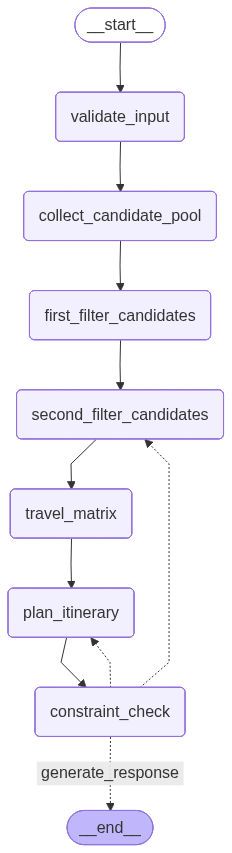

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))